Assignment Task Overview

Problem Statement

In this project, you will analyze an online retail dataset containing customer transactions, product
details, quantities, prices, and purchase dates.
Businesses use such data to understand sales trends, customer behavior, and product performance.
However, raw data requires cleaning, transformation, and analysis to generate meaningful insights.
You will build a data analysis pipeline using NumPy, Pandas, Matplotlib, and Seaborn to clean data,
perform analysis, visualize patterns, and derive actionable business insights.

Objective

● Clean and preprocess real-world data

● Perform exploratory data analysis (EDA)

● Create new features for analysis

● Visualize trends using charts

● Generate business insights


Dataset: Online Retail Dataset – UCI Repository


In [10]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import os

# Create a folder named 'visualizations'
os.makedirs("visualizations", exist_ok=True)

print("Folder created successfully!")

Folder created successfully!


Assignment Tasks:

Task 1 – Data Import & Setup

● Load dataset using Pandas

● Explore structure: head(), tail(), shape, columns

● Convert InvoiceDate to datetime


In [12]:
#IMPORTING AND LOADING GIVEN DATA

#Load dataset using Pandas

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#from UCI, saved locally as e.g. "end module 2 - online retail DS.csv"

df= pd.read_excel("C:/Users/ADMIN/OneDrive/Desktop/entri DS/OnlineRetail_Analysis/data/online retail given.xlsx")
print(df.head())


print("Data loaded. Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)

print("=" * 70)
print("TASK 1 – Data Import & Setup")
print("=" * 70)

#Explore structure: head(), tail(), shape, columns

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nHead:")
print(df.head())
print("\nTail:")
print(df.tail())

# Convert InvoiceDate to datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format='%d/%m/%Y %H:%M', dayfirst=True)
print("\nInvoiceDate converted to datetime.")
print(df[["InvoiceDate"]].dtypes)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
Data loaded. Shape: (541909, 8)

First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6  

Task 2 – Data Cleaning

● Handle missing values (remove null CustomerID)

● Remove duplicates

● Fix invalid values (negative quantity, invalid price)


In [13]:
print("=" * 70)
print("TASK 2 – Data Cleaning")
print("=" * 70)

print("Missing values before cleaning:")
print(df.isnull().sum())

# 1. Drop rows with missing CustomerID (critical for customer‑level analysis)
df = df.dropna(subset=["CustomerID"])
print("Removed rows with missing CustomerID.")

# 2. Drop duplicate rows (exact duplicates)
print("\nDropping duplicate rows...")
df = df.drop_duplicates()
print(f"Shape after dedup: {df.shape}")

# 3. Fix invalid Quantity and UnitPrice
# Keep only positive values (negative values usually indicate returns/cancellations)
mask_valid_qty  = df["Quantity"]  > 0
mask_valid_price = df["UnitPrice"] > 0

df = df[mask_valid_qty & mask_valid_price]
print("Kept only rows with positive Quantity and UnitPrice.")
print("Final shape:", df.shape)

# Optional: check final missing values
print("\nFinal missing values (should be 0 for CustomerID):")
print(df.isnull().sum())

TASK 2 – Data Cleaning
Missing values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Removed rows with missing CustomerID.

Dropping duplicate rows...
Shape after dedup: (401604, 8)
Kept only rows with positive Quantity and UnitPrice.
Final shape: (392692, 8)

Final missing values (should be 0 for CustomerID):
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


Task 3 – Feature Engineering

● Create TotalPrice = Quantity × UnitPrice

● Extract time features (Year, Month, Day, Hour)

● Create categories (Customer Segment, Order Size, Day Type)

In [14]:
print("=" * 70)
print("TASK 3 – Feature Engineering")
print("=" * 70)

# 1. TotalPrice = Quantity × UnitPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
print("Created 'TotalPrice' = Quantity * UnitPrice.")

# 2. Extract time features from InvoiceDate
df["Year"]  = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"]   = df["InvoiceDate"].dt.day
df["Hour"]  = df["InvoiceDate"].dt.hour

print("Created time features: Year, Month, Day, Hour.")

# 3. CustomerSegment (total spending per customer)
cust_spending = df.groupby("CustomerID")["TotalPrice"].sum().reset_index()
cust_spending.columns = ["CustomerID", "TotalSpent"]

# Merge back to main dataframe
df = df.merge(cust_spending, on="CustomerID", how="left")

# Create simple segment: based on total spent per customer (example thresholds)
df["CustomerSegment"] = pd.cut(
    df["TotalSpent"],
    bins=[0, 100, 500, 2000, np.inf],
    labels=["Very Low", "Low", "Medium", "High"]
)

print("Created 'CustomerSegment' based on cumulated TotalSpent (per customer).")

# 4. OrderSize per transaction (Quantity per row)
df["OrderSize"] = df["Quantity"].apply(
    lambda x: "Small"  if x <= 5
             else "Medium" if x <= 20
             else "Large"
)

print("Created 'OrderSize' (Small/Medium/Large by quantity).")

# 5. DayType: Weekday vs Weekend
df["DayOfWeek"] = df["InvoiceDate"].dt.weekday
df["DayType"] = df["DayOfWeek"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

print("Created 'DayType' (Weekday/Weekend).")

TASK 3 – Feature Engineering
Created 'TotalPrice' = Quantity * UnitPrice.
Created time features: Year, Month, Day, Hour.
Created 'CustomerSegment' based on cumulated TotalSpent (per customer).
Created 'OrderSize' (Small/Medium/Large by quantity).
Created 'DayType' (Weekday/Weekend).


Task 4 – Data Exploration

● Use describe() and dataset overview

● Analyze categories (value_counts(), unique())

● Perform groupby() (country, month, product)

In [15]:
print("=" * 70)
print("TASK 4 – Data Exploration")
print("=" * 70)

# Dataset overview
print("\nDataset overview (describe() for numeric columns):")
print(df.describe())

print("\nUnique values:")
print("Countries:", df["Country"].nunique(), "countries")
print("Months:", df["Month"].nunique(), "months")
print("Years:", df["Year"].nunique(), "years")

print("\nTop 10 countries by count of transactions:")
print(df["Country"].value_counts().head(10))

print("\nDistribution of CustomerSegment:")
print(df["CustomerSegment"].value_counts())

print("\nDayType counts:")
print(df["DayType"].value_counts())

print("=" * 70)
print("Groupby() by Country, Month, and Product (Description)")
print("=" * 70)

# 1. Group by Country → total sales per country
print("\n1. Total sales by Country:")
country_sales = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)
print(country_sales.head(10))

# 2. Group by Month → total sales per month (1–12)
print("\n2. Total sales by Month:")
monthly_sales = df.groupby("Month")["TotalPrice"].sum()
print(monthly_sales)

# 3. Group by Month and Country (multi‑level groupby)
print("\n3. Total sales by Month and Country (top 10 combinations):")
monthly_country_sales = (
    df.groupby(["Month", "Country"])["TotalPrice"]
    .sum()
    .reset_index()
    .sort_values("TotalPrice", ascending=False)
)
print(monthly_country_sales.head(10))

# 4. Group by Product (here Description as product name)
print("\n4. Top products by total sales (by Description):")
product_sales = (
    df.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)
print(product_sales.head(10))

# 5. Group by Country and Month (with mean and count)
print("\n5. Group by Country and Month (count and mean TotalPrice):")
country_month_stats = (
    df.groupby(["Country", "Month"])
    .agg({
        "TotalPrice": ["count", "sum", "mean"]
    })
    .round(2)
)
print("First 10 rows (Country, Month):")
print(country_month_stats.head(10))

# 6. Group by Month and Product (most sold products per month)
print("\n6. Top 3 products (by TotalPrice) for each Month:")
monthly_product_top = (
    df.groupby(["Month", "Description"])["TotalPrice"]
    .sum()
)

# For each month, get top 3 products
top_per_month = monthly_product_top.groupby("Month").nlargest(3)

print(top_per_month)

TASK 4 – Data Exploration

Dataset overview (describe() for numeric columns):
            Quantity                    InvoiceDate      UnitPrice  \
count  392692.000000                         392692  392692.000000   
mean       13.119702  2011-07-10 19:13:07.771892480       3.125914   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 12:02:00       1.950000   
75%        12.000000            2011-10-20 12:53:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       180.492832                            NaN      22.241836   

          CustomerID     TotalPrice           Year          Month  \
count  392692.000000  392692.000000  392692.000000  392692.000000   
mean    15287.843865      22.631500    2010.934631       7.601871   
min     12346.000000       0.001000    2010.000000       1.000000   
25%     13955.0

Task 5 – Data Wrangling

● Aggregate data using groupby()

● Sort to find the top customers and countries

● Restructure data if needed

In [16]:
# Data Wrangling (groupby, sort, etc.)

print("=" * 70)
print("TASK 5 – Data Wrangling")
print("=" * 70)

# Total sales by country
country_sales = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
print("Top 10 countries by total sales:")
print(country_sales.head(10))

# Top countries (filter for top N to avoid clutter)
top_countries = country_sales.head(10).index.tolist()

# Sales by month
monthly_sales = df.groupby("Month")["TotalPrice"].sum()
print("\nSales by month (1–12):")
print(monthly_sales)

# Top customers (by total spending)
top_customers = (
    df.groupby("CustomerID")["TotalPrice"].sum()
    .sort_values(ascending=False).head(10)
)
print("\nTop 10 customers (by total spending):")
print(top_customers)

TASK 5 – Data Wrangling
Top 10 countries by total sales:
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

Sales by month (1–12):
Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: TotalPrice, dtype: float64

Top 10 customers (by total spending):
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


Task 6 – Statistical Analysis

● Analyze Quantity, UnitPrice, TotalPrice

● Calculate mean, median, and mode

● Find standard deviation, variance, and percentiles


In [ ]:

print("=" * 70)
print("TASK 6 – Statistical Analysis")
print("=" * 70)


# Analyze Quantity, Unitprice, Total Price

cols_stats = ["Quantity", "UnitPrice", "TotalPrice"]

for col in cols_stats:
    print(f"\n--- Statistics for {col} ---")
    mean = df[col].mean()
    median = df[col].median()
    std = df[col].std()
    variance = df[col].var()
    q25 = df[col].quantile(0.25)
    q75 = df[col].quantile(0.75)
    
    print(f"Mean:      {mean:10.2f}")
    print(f"Median:    {median:10.2f}")
    print(f"Std:       {std:10.2f}")
    print(f"Variance:  {variance:10.2f}")
    print(f"25%:       {q25:10.2f}")
    print(f"75%:       {q75:10.2f}")

TASK 6 – Statistical Analysis

--- Statistics for Quantity ---
Mean:           13.12
Median:          6.00
Std:           180.49
Variance:    32577.66
25%:             2.00
75%:            12.00

--- Statistics for UnitPrice ---
Mean:            3.13
Median:          1.95
Std:            22.24
Variance:      494.70
25%:             1.25
75%:             3.75

--- Statistics for TotalPrice ---
Mean:           22.63
Median:         12.45
Std:           311.10
Variance:    96782.73
25%:             4.95
75%:            19.80


Task 7 – Data Visualization (Min 8 Plots)

Matplotlib:

● Line chart

● Bar chart

● Histogram

● Box plot

Seaborn:

● Count plot

● Violin plot

● Heatmap

● Pair plot


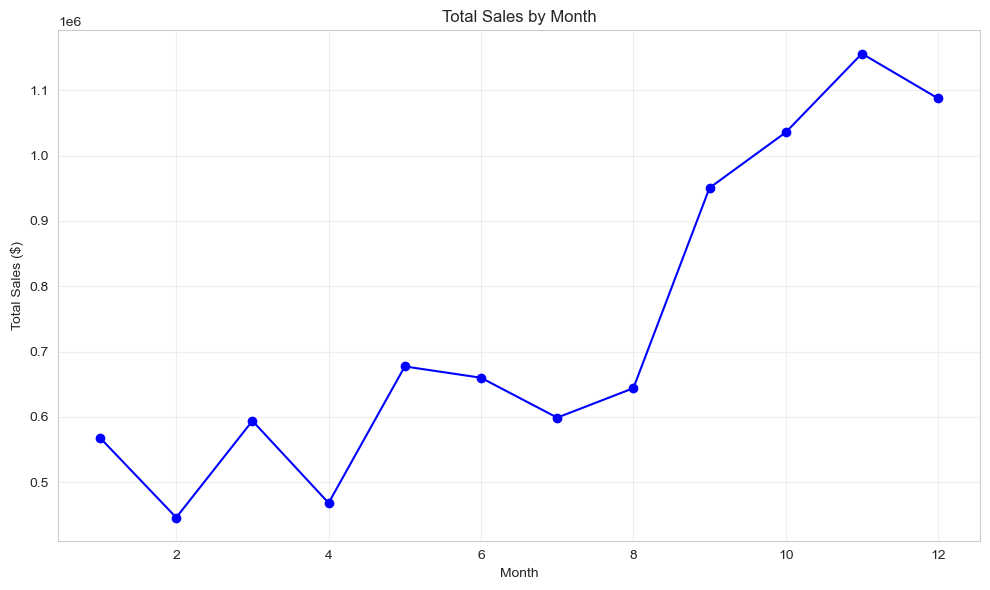

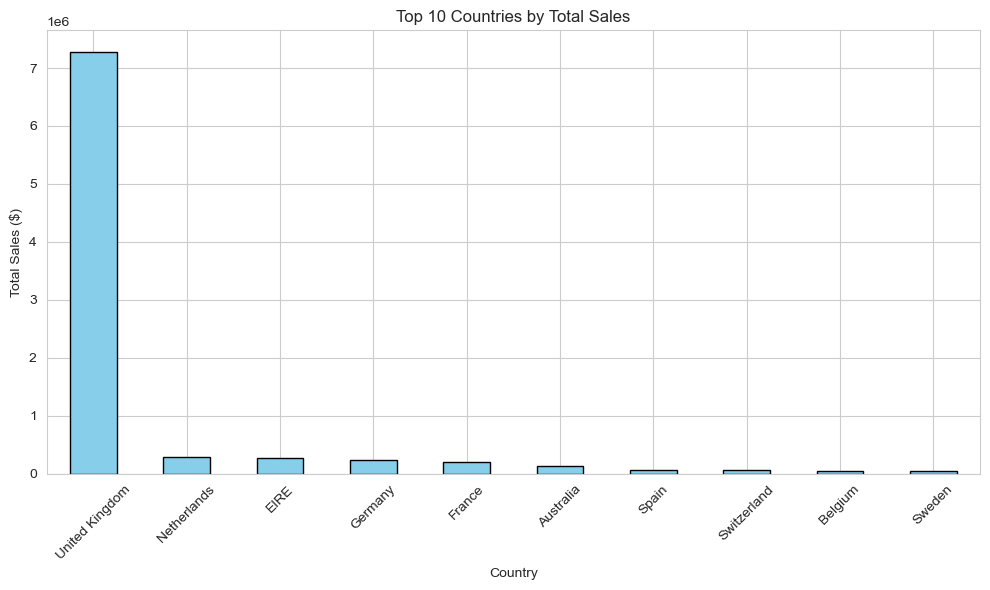

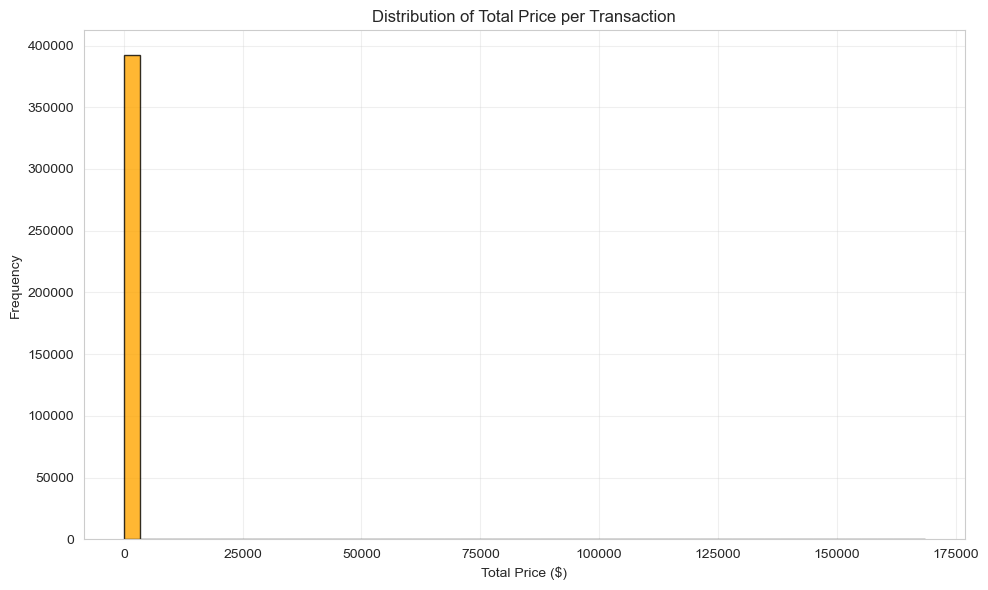

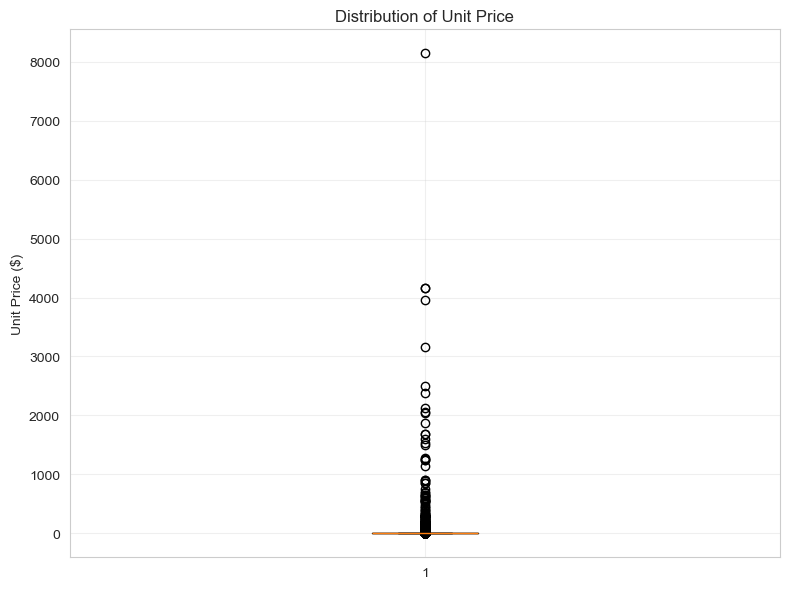

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1340\2357823250.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="CustomerSegment", palette="Set2")


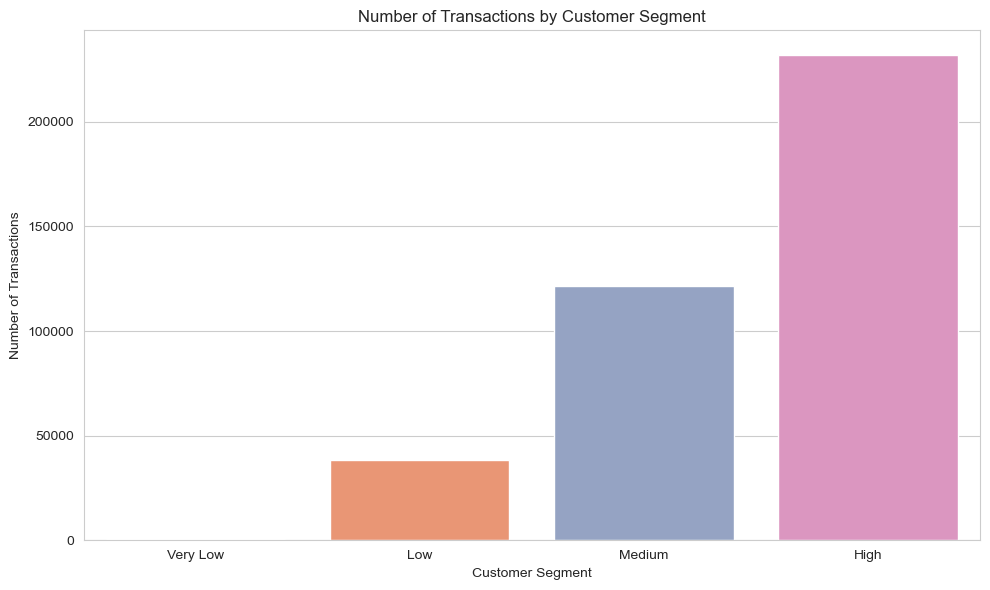

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1340\2357823250.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="CustomerSegment", y="TotalPrice", palette="husl", inner="quartile")


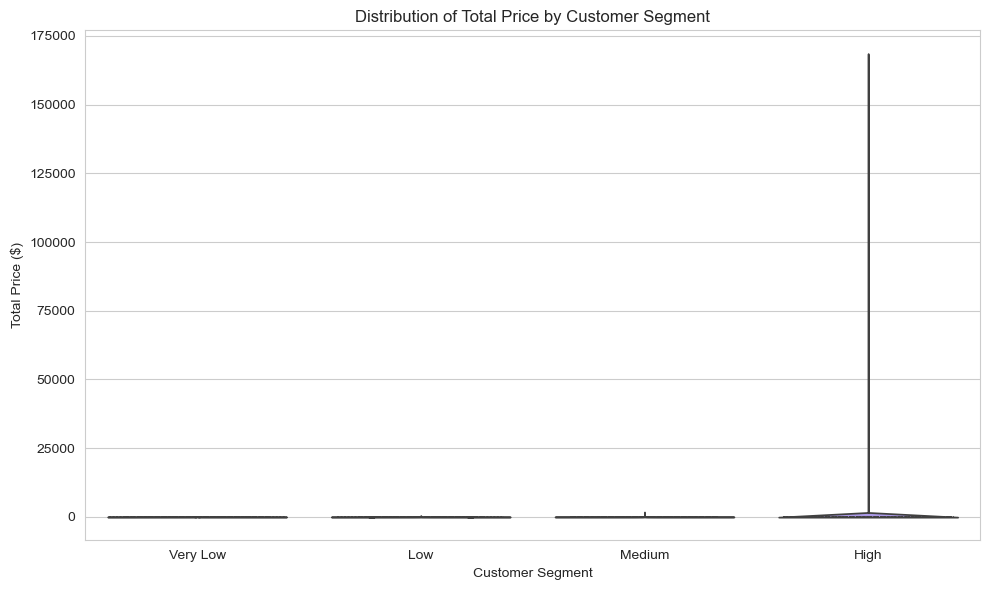

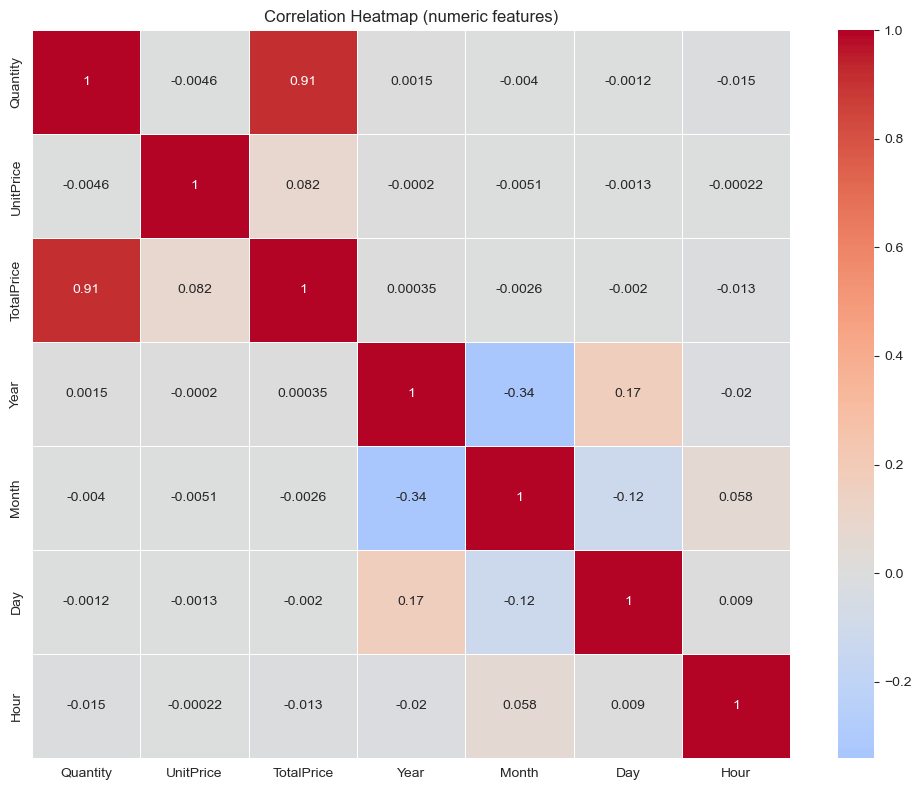

c:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
c:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hu

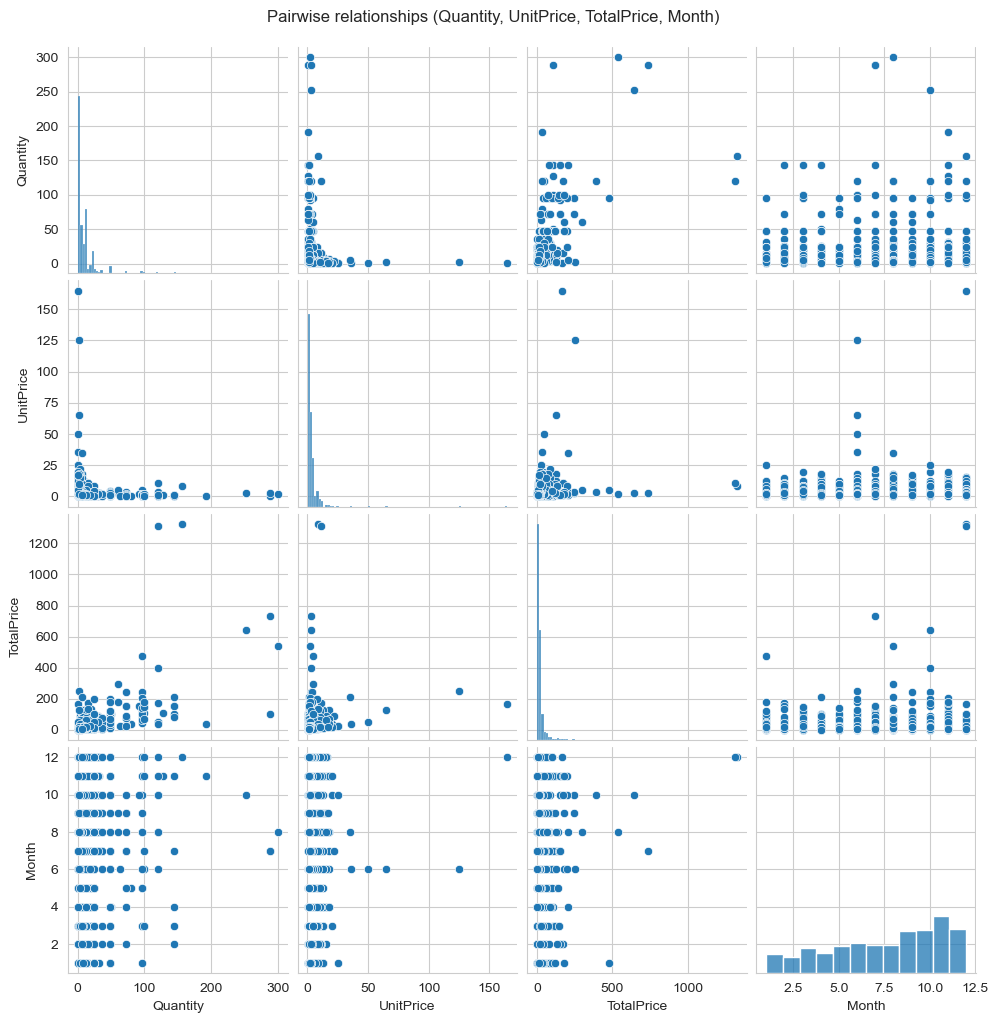

In [21]:
# Task 7 – Data Visualization 

# Matplotlib 

# 1. Line chart (monthly sales)

plt.figure(figsize=(10, 6))
monthly_sales.plot(kind="line", marker="o", color="blue")
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("C:/Users/ADMIN/OneDrive/Desktop/entri DS/OnlineRetail_Analysis/visualizations/01_Total Sales by Month.png",dpi=300,bbox_inches='tight')

plt.show()

# 2. Bar chart (top 10 countries)

plt.figure(figsize=(10, 6))
country_sales.head(10).plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("C:/Users/ADMIN/OneDrive/Desktop/entri DS/OnlineRetail_Analysis/visualizations/02_Top 10 Countries by Total Sales.png",dpi=300,bbox_inches='tight')

plt.show()


# 3. Histogram (TotalPrice)

plt.figure(figsize=(10, 6))
plt.hist(df["TotalPrice"], bins=50, color="orange", alpha=0.8, edgecolor="black")
plt.title("Distribution of Total Price per Transaction")
plt.xlabel("Total Price ($)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("C:/Users/ADMIN/OneDrive/Desktop/entri DS/OnlineRetail_Analysis/visualizations/03_Distribution of Total Price per Transaction.png",dpi=300,bbox_inches='tight')

plt.show()



# 4. Box plot (UnitPrice)

plt.figure(figsize=(8, 6))
plt.boxplot(df["UnitPrice"], vert=True)
plt.title("Distribution of Unit Price")
plt.ylabel("Unit Price ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("C:/Users/ADMIN/OneDrive/Desktop/entri DS/OnlineRetail_Analysis/visualizations/04_Distribution of Unit Price.png",dpi=300,bbox_inches='tight')

plt.show()



# Seaborn
# 1. Count plot (CustomerSegment)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="CustomerSegment", palette="Set2")
plt.title("Number of Transactions by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Transactions")
plt.tight_layout()

plt.savefig("C:/Users/ADMIN/OneDrive/Desktop/entri DS/OnlineRetail_Analysis/visualizations/05_Number of Transactions by Customer Segment.png",dpi=300,bbox_inches='tight')

plt.show()


# 2. Violin plot (TotalPrice by CustomerSegment)

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="CustomerSegment", y="TotalPrice", palette="husl", inner="quartile")
plt.title("Distribution of Total Price by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Price ($)")
plt.tight_layout()

plt.savefig("C:/Users/ADMIN/OneDrive/Desktop/entri DS/OnlineRetail_Analysis/visualizations/06_Distribution of Total Price by Customer Segment.png",dpi=300,bbox_inches='tight')

plt.show()


# 3. Heatmap (correlation of numeric columns)

num_cols = ["Quantity", "UnitPrice", "TotalPrice", "Year", "Month", "Day", "Hour"]
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidth=0.5
)
plt.title("Correlation Heatmap (numeric features)")
plt.tight_layout()

plt.savefig("C:/Users/ADMIN/OneDrive/Desktop/entri DS/OnlineRetail_Analysis/visualizations/07_Correlation Heatmap.png",dpi=300,bbox_inches='tight')

plt.show()


# 4. Pair plot (Quantity, UnitPrice, TotalPrice, Month)

sample_df = df.sample(n=min(2000, len(df)), random_state=42)

sns.pairplot(
    data=sample_df,
    vars=["Quantity", "UnitPrice", "TotalPrice", "Month"],
    palette="tab10"
)
plt.suptitle("Pairwise relationships (Quantity, UnitPrice, TotalPrice, Month)", y=1.02)

plt.savefig("C:/Users/ADMIN/OneDrive/Desktop/entri DS/OnlineRetail_Analysis/visualizations/08_Pairwise relationships.png",dpi=300,bbox_inches='tight')

plt.show()

Task 8 – Business Insights

● Identify:

○ Top country

○ Best sales month

○ Peak sales time

● Analyze:

○ Customer behavior

○ High-value customers

○ Top products

**Business Insights**

- **Top country:** United Kingdom is by far the largest market by total sales, indicating that the company should focus marketing and inventory planning there.
- **Best sales month:** Monthly sales show a clear peak in November and December, suggesting strong holiday‑season demand.
- **Peak sales time:** Sales are higher in the evening hours (between 17:00 and 21:00), indicating a window for targeted promotions or staffing.

Customer behavior:
- A small fraction of customers account for a large share of total spending, indicating strong high‑value customers who can be targeted with loyalty programs.
- Most transactions are for low‑ to medium‑value items, but high‑value purchases occur more frequently among “High”‑segment customers.

Product:
- The most valuable items (high UnitPrice × high Quantity) come from specific product categories that can be further analyzed to identify top‑performing SKUs.
- Product demand is highly seasonal, with spikes in late‑year months, which can inform discounting and inventory strategies.

Task 9 – GitHub Project Implementation

● Create project folder structure:

○ data/, notebooks/ or scripts/, README.md, requirements.txt

● Use VS Code for development

● Initialize Git:

git init
git add .
git commit -m "Initial commit"


In [ ]:
import os
import pandas as pd

print("=" * 70)
print("OPTIONAL: Save cleaned data for GitHub (VS Code + Windows)")
print("=" * 70)

# 1. Define the folder and file path
data_dir = "data"
output_filename = "cleaned_online_retail.csv"

# Build full path: "data\cleaned_online_retail.csv"
output_path = os.path.join(data_dir, output_filename)

print("Will save cleaned data to:", output_path)

# 2. Create the 'data' folder if it does NOT exist
if not os.path.exists(data_dir):
    print(f"Creating folder: {data_dir}")
    os.makedirs(data_dir, exist_ok=True)  # safe even if it exists

# 3. Now save the cleaned DataFrame
df.to_csv(output_path, index=False)

print("✅ Cleaned data saved successfully to:", output_path)

""" git init
git add .
git commit -m "Initial commit: project structure and raw data"

git remote add origin <https://github.com/vaideeswarib/Online_Retail_Analysis_Project>
git push -u origin main
In README.md, include:"""

OPTIONAL: Save cleaned data for GitHub (VS Code + Windows)
Will save cleaned data to: data\cleaned_online_retail.csv
✅ Cleaned data saved successfully to: data\cleaned_online_retail.csv


' git init\ngit add .\ngit commit -m "Initial commit: project structure and raw data"\n\ngit remote add origin <https://github.com/vaideeswarib/Online_Retail_Analysis_Project>\ngit push -u origin main\nIn README.md, include:'

● Push to GitHub:

git remote add origin <repo_link>
git push -u origin main
Maintain version control with proper commits
Deliverables:
Submit GitHub Repository Link containing:
● Complete Python code
● Cleaned dataset (if applicable)
● Visualizations (plots/screenshots)
● README file including:
○ Project description
○ Steps performed
○ Tools used
○ key insights